# Collect Results for Paper Figures

This notebook is a paper-facing analysis notebook for the Sachs benchmark slice.

It assumes the following files already exist under `experiments/responses/sachs/`:
- `sachs_summary.csv`
- `sachs_all_systems.csv`
- `sachs_main_cohort.csv`

The notebook focuses on five analysis blocks:
1. the clean paper cohort,
2. classical-vs-LLM comparison,
3. prompt-representation sensitivity,
4. semantic-prior audit,
5. a separate Qwen/GRPO comparison on shared Sachs settings.

The main paper analysis uses `avg_*` metrics rather than consensus metrics.
All figures are saved under `experiments/responses/sachs/paper_figures/`.


In [12]:
%config InlineBackend.figure_format = 'svg'

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

# ── Path resolution ────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().parent
if REPO_ROOT.name == 'experiments' and not (REPO_ROOT / 'responses').exists():
    REPO_ROOT = REPO_ROOT.parent
elif not (REPO_ROOT / 'experiments').exists() and (REPO_ROOT.parent / 'experiments').exists():
    REPO_ROOT = REPO_ROOT.parent

GRAPH_NAME    = 'sachs'
RESPONSES_DIR = REPO_ROOT / 'experiments' / 'responses' / GRAPH_NAME
RAW_SUMMARY_CSV = RESPONSES_DIR / 'sachs_summary.csv'
ALL_SYSTEMS_CSV = RESPONSES_DIR / 'sachs_all_systems.csv'
MAIN_COHORT_CSV = RESPONSES_DIR / 'sachs_main_cohort.csv'
FIG_DIR   = RESPONSES_DIR / 'paper_figures'
TABLE_DIR = RESPONSES_DIR / 'paper_tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── NeurIPS figure style ───────────────────────────────────────────────────────
FONT_SIZE   = 8      # axis labels
TICK_SIZE   = 7      # tick labels
LEGEND_SIZE = 7
LW          = 1.2    # default line width
COL1_W      = 3.25   # single-column figure width (inches)
COL2_W      = 6.75   # double-column figure width (inches)
FIG_H       = 2.4    # standard panel height

mpl.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':          FONT_SIZE,
    'axes.labelsize':     FONT_SIZE,
    'axes.titlesize':     FONT_SIZE,
    'xtick.labelsize':    TICK_SIZE,
    'ytick.labelsize':    TICK_SIZE,
    'legend.fontsize':    LEGEND_SIZE,
    'legend.framealpha':  0.85,
    'legend.edgecolor':   '0.8',
    'lines.linewidth':    LW,
    'axes.linewidth':     0.6,
    'xtick.major.width':  0.6,
    'ytick.major.width':  0.6,
    'grid.linewidth':     0.4,
    'grid.alpha':         0.4,
    'figure.dpi':         150,       # screen preview; savefig overrides to 300
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.02,
})

sns.set_style('ticks')

# Okabe-Ito colorblind-safe palette (via seaborn 'colorblind')
PALETTE_CB = sns.color_palette('colorblind')

# sachs_main_cohort.csv uses 'summary' (pre-refactor); sachs_summary.csv uses 'summary_joint'
SETTING_LABELS = {
    'name only':     'Names only',
    'names_only':    'Names only',
    'summary':       'Summary',       # pre-refactor label in sachs_main_cohort
    'summary_joint': 'Summary',       # current label in sachs_summary
    'matrix':        'Matrix',
    'ENCO':          'ENCO',
}

def save_fig(fig, stem, formats=('pdf', 'png')):
    """Save figure under FIG_DIR in each requested format."""
    for fmt in formats:
        out = FIG_DIR / f'{stem}.{fmt}'
        fig.savefig(out, format=fmt)
    print(f'Saved → {stem}')

In [13]:
raw_summary = pd.read_csv(RAW_SUMMARY_CSV)
all_systems = pd.read_csv(ALL_SYSTEMS_CSV)
main = pd.read_csv(MAIN_COHORT_CSV)

print('Raw summary:', raw_summary.shape)
print('All systems:', all_systems.shape)
print('Main cohort:', main.shape)

display(main.sort_values(['obs_n', 'int_n', 'system_kind', 'system', 'prompt_style', 'naming_regime']).reset_index(drop=True))


FileNotFoundError: [Errno 2] No such file or directory: '/home/yuen_chen/ENCO/experiments/responses/sachs/sachs_all_systems.csv'

## Main comparison tables

These tables are the paper-facing views for Sachs. The main analysis uses `avg_f1` and `avg_shd`.


In [14]:
main_table = main[[
    'system', 'system_kind', 'prompt_style', 'naming_regime',
    'obs_n', 'int_n', 'avg_f1', 'avg_shd', 'valid_rows', 'num_rows', 'source_file'
]].sort_values(['obs_n', 'int_n', 'system_kind', 'system', 'prompt_style', 'naming_regime']).reset_index(drop=True)

display(main_table)


NameError: name 'main' is not defined

In [15]:
repr_table = (
    main[
        (main['system'] == 'gpt-5-mini')
        & (main['prompt_style'].isin(['summary', 'matrix']))  # 'summary' is pre-refactor name
    ]
    .pivot_table(
        index=['obs_n', 'int_n', 'naming_regime'],
        columns='prompt_style',
        values=['avg_f1', 'avg_shd'],
        aggfunc='first',
    )
    .sort_index()
)

repr_table

NameError: name 'main' is not defined

In [16]:
AUDIT_PROMPT = 'summary'  # pre-refactor name in sachs_main_cohort.csv

full_info = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == AUDIT_PROMPT)
].copy()

names_only = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == 'names_only')
].copy()

if names_only.empty:
    raise ValueError('No names_only row found in main cohort.')

names_only_row = names_only.iloc[0]
real = full_info[full_info['naming_regime'] == 'real'].copy()
anon = full_info[full_info['naming_regime'] == 'anonymized'].copy()

semantic_audit = real.merge(
    anon,
    on=['obs_n', 'int_n', 'prompt_style', 'system', 'system_kind'],
    suffixes=('_real', '_anon'),
)
semantic_audit['names_only_f1']  = float(names_only_row['avg_f1'])
semantic_audit['names_only_shd'] = float(names_only_row['avg_shd'])
semantic_audit['real_minus_anon_f1']        = semantic_audit['avg_f1_real'] - semantic_audit['avg_f1_anon']
semantic_audit['real_minus_names_only_f1']  = semantic_audit['avg_f1_real'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_names_only_f1']  = semantic_audit['avg_f1_anon'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_real_shd']       = semantic_audit['avg_shd_anon'] - semantic_audit['avg_shd_real']
semantic_audit = semantic_audit[[
    'obs_n', 'int_n',
    'avg_f1_real', 'avg_f1_anon', 'names_only_f1',
    'real_minus_anon_f1', 'real_minus_names_only_f1', 'anon_minus_names_only_f1',
    'avg_shd_real', 'avg_shd_anon', 'names_only_shd', 'anon_minus_real_shd',
]].sort_values(['obs_n', 'int_n'])

semantic_audit

NameError: name 'main' is not defined

## Main paper figures

The figures below correspond to the main benchmark story:
- representation sensitivity,
- semantic-prior audit,
- classical-vs-LLM budget curves.


In [17]:
# ── Build curve data ──────────────────────────────────────────────────────────
# sachs_main_cohort uses 'summary' (pre-refactor); filter accordingly
curve_df = main[main['system'].isin(['ENCO', 'PC', 'GES', 'gpt-5-mini'])].copy()
curve_df = curve_df[
    (curve_df['prompt_style'].isin(['classical', 'summary']))
    | ((curve_df['system'] == 'gpt-5-mini') & (curve_df['prompt_style'] == 'names_only'))
].copy()
curve_df['display_system'] = curve_df.apply(
    lambda r: r['system'] if r['system_kind'] == 'classical'
    else ('GPT-5-mini (summary)' if r['prompt_style'] == 'summary'
          else 'GPT-5-mini (names only)'),
    axis=1,
)

obs_focus  = 100
plot_curve = curve_df[
    (curve_df['obs_n'] == obs_focus) | (curve_df['prompt_style'] == 'names_only')
].copy()
plot_curve.loc[plot_curve['prompt_style'] == 'names_only', 'int_n'] = 0

# ── Visual encoding: color + marker + linestyle per system ────────────────────
SYS_STYLE = {
    'ENCO':                    dict(color=PALETTE_CB[3], marker='s',  ls='-'),
    'PC':                      dict(color=PALETTE_CB[4], marker='^',  ls='--'),
    'GES':                     dict(color=PALETTE_CB[5], marker='D',  ls='-.'),
    'GPT-5-mini (summary)':    dict(color=PALETTE_CB[0], marker='o',  ls='-'),
    'GPT-5-mini (names only)': dict(color=PALETTE_CB[2], marker='x',  ls=':'),
}

fig, ax = plt.subplots(figsize=(COL2_W, FIG_H))

for sys, style in SYS_STYLE.items():
    sub = plot_curve[plot_curve['display_system'] == sys].sort_values('int_n')
    if sub.empty:
        continue
    ax.plot(sub['int_n'], sub['avg_f1'], label=sys,
            markersize=4, markeredgewidth=0.6, **style)

ax.set_xlabel('Interventional budget (# samples)')
ax.set_ylabel('Avg. F1')
ax.set_title(f'Sachs — data budget comparison (obs = {obs_focus})')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.legend(ncol=2, loc='lower right')
sns.despine(ax=ax)
fig.tight_layout()

save_fig(fig, f'sachs_budget_curve_obs{obs_focus}_avg_f1')
plt.show()

NameError: name 'main' is not defined

In [20]:
raw_summary = pd.read_csv(RAW_SUMMARY_CSV)

# ── Model display names — edit this dict to add / remove models ───────────────
PRETTY_MODEL = {
    'ENCO':                   'ENCO',
    'gpt-5-mini':             'GPT-5-mini',
    'gpt-5.2-pro':            'GPT-5.2-pro',
    'Qwen3-4B-Thinking-2507': 'Qwen3-4B (base)',
    'checkpoint-300_merged_vllm': 'Ckpt-300 (merged)',
}

model_order        = list(PRETTY_MODEL.values())
real_setting_order = ['name only', 'summary_joint', 'matrix', 'ENCO']
anon_setting_order = ['summary_joint', 'matrix', 'ENCO']

# ── Full-information slice (obs=5000, int=200) ─────────────────────────────────
llm_full_info = raw_summary[
    raw_summary['model'].isin([m for m in PRETTY_MODEL if m != 'ENCO'])
    & (raw_summary['obs_n'].fillna(-1) == 5000)
    & (raw_summary['int_n'].fillna(-1) == 200)
    & (raw_summary['prompt_style'].isin(['summary_joint', 'matrix']))
].copy()

enco_full_info = raw_summary[
    (raw_summary['model'] == 'ENCO')
    & (raw_summary['obs_n'].fillna(-1) == 5000)
    & (raw_summary['int_n'].fillna(-1) == 200)
    & (raw_summary['prompt_style'] == 'enco')
].copy()

full_info = pd.concat([llm_full_info, enco_full_info], ignore_index=True)
full_info['display_model'] = full_info['model'].map(PRETTY_MODEL)
full_info = full_info[full_info['display_model'].notna()].copy()
full_info['setting'] = full_info['prompt_style'].replace({'enco': 'ENCO'})

# ── Names-only control ────────────────────────────────────────────────────────
name_only = raw_summary[
    raw_summary['model'].isin(PRETTY_MODEL)
    & (raw_summary['prompt_style'] == 'names_only')
].copy()
name_only['display_model'] = name_only['model'].map(PRETTY_MODEL)
name_only = name_only[name_only['display_model'].notna()].copy()
name_only['setting'] = 'name only'

for df in [full_info, name_only]:
    df['display_model'] = pd.Categorical(
        df['display_model'], categories=model_order, ordered=True
    )

display(
    full_info[[
        'display_model', 'anonymize', 'setting',
        'avg_f1', 'avg_f1_sd', 'avg_shd', 'avg_shd_sd', 'valid_rows',
    ]].sort_values(['display_model', 'anonymize', 'setting']).reset_index(drop=True)
)

,display_model,anonymize,setting,avg_f1,avg_f1_sd,avg_shd,avg_shd_sd,valid_rows
0,GPT-5-mini,0,matrix,0.353291,0.069102,17.4,1.140175,5.0
1,GPT-5-mini,1,matrix,NaN,NaN,17.0,0.000000,5.0
2,GPT-5.2-pro,0,matrix,0.542796,0.084347,13.8,2.489980,5.0
3,GPT-5.2-pro,1,matrix,0.214129,0.051090,23.4,1.516575,5.0
4,Qwen3-4B (base),0,matrix,0.444444,0.000000,15.0,0.000000,3.0
5,Qwen3-4B (base),1,matrix,0.395195,0.150114,18.6,5.366563,5.0
6,Ckpt-300 (merged),0,matrix,NaN,NaN,NaN,NaN,0.0
7,Ckpt-300 (merged),0,matrix,NaN,NaN,NaN,NaN,0.0
8,Ckpt-300 (merged),0,matrix,NaN,NaN,NaN,NaN,0.0
9,Ckpt-300 (merged),1,matrix,NaN,NaN,NaN,NaN,0.0


Saved → sachs_f1_comparison


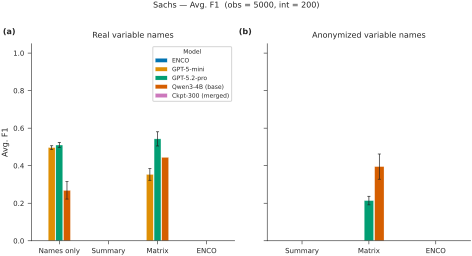

Saved → sachs_shd_comparison


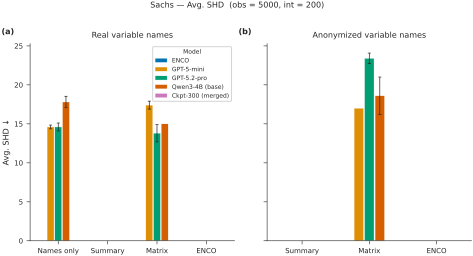

In [21]:
# ── Aggregate mean + SE for plotting ──────────────────────────────────────────
PLOT_METRICS = ['avg_f1', 'avg_f1_sd', 'avg_shd', 'avg_shd_sd', 'valid_rows']

def build_plot_df(src, setting_order, model_order):
    """Collapse to one row per (model, setting); propagate SE for error bars."""
    df = src[['display_model', 'setting'] + PLOT_METRICS].copy()
    for c in PLOT_METRICS:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = (
        df.groupby(['display_model', 'setting'], observed=True)
        .agg(**{c: (c, 'mean') for c in PLOT_METRICS})
        .reset_index()
    )
    n = df['valid_rows'].clip(lower=1)
    df['f1_se']  = df['avg_f1_sd']  / n.pow(0.5)
    df['shd_se'] = df['avg_shd_sd'] / n.pow(0.5)
    df['display_model'] = pd.Categorical(
        df['display_model'], categories=model_order, ordered=True)
    df['setting'] = pd.Categorical(
        df['setting'], categories=setting_order, ordered=True)
    return df

real_src = pd.concat(
    [full_info[full_info['anonymize'].fillna(0).astype(int) == 0], name_only],
    ignore_index=True,
)
anon_src = full_info[full_info['anonymize'].fillna(0).astype(int) == 1].copy()

real_df = build_plot_df(real_src, real_setting_order, model_order)
anon_df = build_plot_df(anon_src, anon_setting_order, model_order)

# One color per model, reused across all figures
palette     = sns.color_palette('colorblind', n_colors=len(model_order))
model_color = dict(zip(model_order, palette))

# ── Grouped bar + ±1 SE error-cap helper ──────────────────────────────────────
def draw_grouped_bars(ax, df, metric, err_col, setting_order, model_order,
                      model_color, ylabel=None, title=None,
                      panel_label=None, show_legend=False):
    n_s     = len(setting_order)
    n_m     = len(model_order)
    width   = 0.78 / n_m
    offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * width
    x = np.arange(n_s)

    for i, model in enumerate(model_order):
        sub  = (df[df['display_model'] == model]
                .set_index('setting')
                .reindex(setting_order))
        vals = sub[metric].values
        errs = sub[err_col].fillna(0).values

        ax.bar(x + offsets[i],
               np.where(np.isnan(vals), 0, vals),
               width=width * 0.9,
               color=model_color[model],
               label=model,
               edgecolor='white', linewidth=0.3)

        for j, (v, e) in enumerate(zip(vals, errs)):
            if not np.isnan(v) and e > 0:
                ax.errorbar(x[j] + offsets[i], v, yerr=e,
                            fmt='none', color='#222222',
                            elinewidth=0.7, capsize=1.5, capthick=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([SETTING_LABELS.get(s, s) for s in setting_order])
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if panel_label:
        ax.text(-0.14, 1.04, panel_label, transform=ax.transAxes,
                fontsize=FONT_SIZE, fontweight='bold', va='bottom')
    if show_legend:
        ax.legend(title='Model', ncol=1,
                  fontsize=LEGEND_SIZE - 1, title_fontsize=LEGEND_SIZE - 1,
                  loc='upper right')
    sns.despine(ax=ax)

# ── Figure 1: Avg. F1 (real | anonymized) ─────────────────────────────────────
fig_f1, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_df, 'avg_f1', 'f1_se',
                  real_setting_order, model_order, model_color,
                  ylabel='Avg. F1', title='Real variable names',
                  panel_label='(a)', show_legend=True)
axes[0].set_ylim(0, 1.05)

draw_grouped_bars(axes[1], anon_df, 'avg_f1', 'f1_se',
                  anon_setting_order, model_order, model_color,
                  title='Anonymized variable names',
                  panel_label='(b)')
axes[1].set_ylim(0, 1.05)

fig_f1.suptitle('Sachs — Avg. F1  (obs = 5000, int = 200)',
                fontsize=FONT_SIZE, y=1.01)
fig_f1.tight_layout()
save_fig(fig_f1, 'sachs_f1_comparison')
plt.show()

# ── Figure 2: Avg. SHD (real | anonymized) ────────────────────────────────────
fig_shd, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_df, 'avg_shd', 'shd_se',
                  real_setting_order, model_order, model_color,
                  ylabel='Avg. SHD ↓', title='Real variable names',
                  panel_label='(a)', show_legend=True)

draw_grouped_bars(axes[1], anon_df, 'avg_shd', 'shd_se',
                  anon_setting_order, model_order, model_color,
                  title='Anonymized variable names',
                  panel_label='(b)')

fig_shd.suptitle('Sachs — Avg. SHD  (obs = 5000, int = 200)',
                 fontsize=FONT_SIZE, y=1.01)
fig_shd.tight_layout()
save_fig(fig_shd, 'sachs_shd_comparison')
plt.show()

## Valid response rate

How often did each model produce a parseable answer?  
`valid_rate = valid_rows / num_rows` aggregated (weighted sum) across all obs/int slices per condition.

In [4]:
# ── Valid response rate by prompt configuration (pretrained LLMs) ────────────
# raw_summary contains many newer Llama/Qwen runs, while all_systems carries GPT rows.
# Combine both and de-duplicate by response filename.
raw_llm = raw_summary[
    (raw_summary['model'] != 'ENCO')
    & raw_summary['num_rows'].notna()
    & (raw_summary['num_rows'] > 0)
].copy()
raw_llm['source_file'] = raw_llm['response_csv'].map(lambda x: Path(x).name if pd.notna(x) else '')
raw_llm['naming_regime'] = np.where(
    raw_llm['prompt_style'].eq('names_only'),
    'names_only',
    raw_llm['anonymize'].fillna(0).astype(int).map({0: 'real', 1: 'anonymized'})
)
raw_llm = raw_llm[[
    'model', 'prompt_style', 'obs_n', 'int_n', 'naming_regime',
    'valid_rows', 'num_rows', 'source_file',
]].copy()

curated_llm = all_systems[
    (all_systems['system_kind'] == 'llm')
    & all_systems['num_rows'].notna()
    & (all_systems['num_rows'] > 0)
][[
    'model', 'prompt_style', 'obs_n', 'int_n', 'naming_regime',
    'valid_rows', 'num_rows', 'source_file',
]].copy()

llm_vr = (
    pd.concat([raw_llm, curated_llm], ignore_index=True)
    .assign(source_file=lambda d: d['source_file'].fillna('').astype(str))
    .drop_duplicates(subset=['source_file'], keep='first')
)

LOCAL_POSTTRAINED_MODELS = {
    'sft',
    'staged_sft_v3',
    'grpo_sachs_mix_onthefly_mp2',
    'grpo_sft_8192',
    'grpo_sft_8192_cd_focus',
    'grpo_sft_8192_from4096',
    'grpo_v2_cancer_eq',
    'qwen3_4b_cd_format_v4',
    'qwen3_4b_cd_format_v5',
    'stage_3_obs100_int0_bootstrap',
    'stage_3_obs100_int0_graph_scaled',
    'stage_3_obs100_int0_retuned',
}
LOCAL_POSTTRAINED_PREFIXES = ('checkpoint-', 'grpo_', 'stage_')

pretrained_vr = llm_vr[
    ~llm_vr['model'].isin(LOCAL_POSTTRAINED_MODELS)
    & ~llm_vr['model'].astype(str).str.startswith(LOCAL_POSTTRAINED_PREFIXES)
].copy()

vr_cfg = pretrained_vr[
    pretrained_vr['prompt_style'].isin(['names_only', 'summary', 'summary_joint', 'matrix'])
].copy()
vr_cfg['obs_n_cfg'] = vr_cfg['obs_n'].fillna(0).astype(int)
vr_cfg['int_n_cfg'] = vr_cfg['int_n'].fillna(0).astype(int)
vr_cfg['naming_regime'] = np.where(
    vr_cfg['prompt_style'].eq('names_only'),
    'real',
    vr_cfg['naming_regime'].replace({'anonymized': 'anon', 'real': 'real'})
)
vr_cfg['source_file'] = vr_cfg['source_file'].fillna('').astype(str)
src_lower = vr_cfg['source_file'].str.lower()
vr_cfg['prompt_count_cfg'] = (
    vr_cfg['source_file'].str.extract(r'_p(\d+)_', expand=False).fillna('0').astype(int)
)
vr_cfg['wrapper_variant'] = np.select(
    [
        src_lower.str.contains('wrapchat', regex=False),
        src_lower.str.contains('thinktags', regex=False),
    ],
    ['wrapchat', 'thinktags'],
    default='plain'
)
vr_cfg['hint_variant'] = np.select(
    [
        src_lower.str.contains('fmthint', regex=False),
        src_lower.str.contains('cothint', regex=False),
        src_lower.str.contains('respthink_answer', regex=False),
    ],
    ['fmthint', 'cothint', 'respthink_answer'],
    default='none'
)
vr_cfg['special_variant'] = np.select(
    [
        vr_cfg['source_file'].str.contains('colReverse_topo', regex=False),
        vr_cfg['source_file'].str.contains('colReverse', regex=False),
        vr_cfg['source_file'].str.contains('colRandom', regex=False),
        vr_cfg['source_file'].str.contains('colTopo', regex=False),
        vr_cfg['source_file'].str.contains('_shuf1_', regex=False),
    ],
    ['colReverse_topo', 'colReverse', 'colRandom', 'colTopo', 'shuf1_only'],
    default='standard'
)
vr_cfg['shuffles_cfg'] = (
    vr_cfg['source_file'].str.extract(r'_shuf(\d+)_', expand=False).fillna('0').astype(int)
)
vr_cfg['per_run_valid_rate'] = vr_cfg['valid_rows'] / vr_cfg['num_rows']

PROMPT_STYLE_LABELS = {
    'names_only': 'Names only',
    'summary': 'Summary',
    'summary_joint': 'Summary joint',
    'matrix': 'Matrix',
}

config_rank = (
    vr_cfg.groupby([
        'prompt_style', 'obs_n_cfg', 'int_n_cfg', 'naming_regime',
        'wrapper_variant', 'hint_variant', 'special_variant', 'shuffles_cfg',
    ], observed=True)
    .agg(
        p_values=('prompt_count_cfg', lambda s: ','.join(str(int(v)) for v in sorted({v for v in s if v > 0})) or 'unspecified'),
        prompt_count_variants=('prompt_count_cfg', lambda s: int(len({v for v in s if v > 0}))),
        total_valid=('valid_rows', 'sum'),
        total_n=('num_rows', 'sum'),
        model_runs=('model', 'count'),
        model_count=('model', 'nunique'),
        mean_run_valid_rate=('per_run_valid_rate', 'mean'),
        median_run_valid_rate=('per_run_valid_rate', 'median'),
    )
    .assign(valid_rate=lambda d: d['total_valid'] / d['total_n'])
    .reset_index()
    .sort_values(
        ['valid_rate', 'model_count', 'total_n', 'mean_run_valid_rate'],
        ascending=[False, False, False, False],
    )
    .reset_index(drop=True)
)
config_rank.insert(0, 'rank', np.arange(1, len(config_rank) + 1))
config_rank[['valid_rate', 'mean_run_valid_rate', 'median_run_valid_rate']] = (
    config_rank[['valid_rate', 'mean_run_valid_rate', 'median_run_valid_rate']].round(3)
)
config_rank = config_rank.rename(columns={'total_valid': 'valid_n'})

def format_prompt_config_label(row):
    parts = [
        PROMPT_STYLE_LABELS.get(row['prompt_style'], row['prompt_style']),
        f"obs={row['obs_n_cfg']}, int={row['int_n_cfg']}",
        row['naming_regime'],
        row['wrapper_variant'],
    ]
    if row['hint_variant'] != 'none':
        parts.append(f"hint={row['hint_variant']}")
    if row['special_variant'] != 'standard':
        parts.append(f"variant={row['special_variant']}")
    if row['shuffles_cfg'] > 0:
        parts.append(f"shuf={row['shuffles_cfg']}")
    return ' | '.join(parts)

config_rank['config_label'] = config_rank.apply(format_prompt_config_label, axis=1)

heatmap_df = config_rank.set_index('config_label')[['valid_rate']].rename(
    columns={'valid_rate': 'Valid rate'}
)

fig_vr, ax = plt.subplots(figsize=(COL2_W * 0.95, max(2.4, 0.28 * len(heatmap_df) + 0.8)))
sns.heatmap(
    heatmap_df,
    ax=ax,
    vmin=0, vmax=1,
    cmap='YlGn',
    annot=True, fmt='.2f',
    linewidths=0.4,
    cbar_kws=dict(label='Valid response rate', shrink=0.75),
    annot_kws=dict(size=TICK_SIZE),
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Valid response rate by prompt configuration (pretrained LLMs)', fontsize=FONT_SIZE)
ax.tick_params(axis='x', labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=max(TICK_SIZE - 1, 5), rotation=0)
fig_vr.tight_layout()
save_fig(fig_vr, 'sachs_valid_response_rate_by_prompt_config_pretrained')
plt.show()

print('Pretrained models included:', sorted(vr_cfg['model'].dropna().unique().tolist()))
display(config_rank.drop(columns=['config_label']))

config_rank.drop(columns=['config_label']).to_csv(
    TABLE_DIR / 'sachs_valid_rate_prompt_config_rank_pretrained.csv', index=False
)
print('Saved → sachs_valid_rate_prompt_config_rank_pretrained.csv')


NameError: name 'all_systems' is not defined

## Qwen / GRPO comparison

This section is separate from the main benchmark cohort. It compares the pretrained Qwen model
against the SFT / GRPO variants on the Sachs settings they actually share.

By default, it uses the strongest shared slice we currently have in this folder:
- `names_only` with `p5`, and
- `thinktags` runs at `obs=0`, `int=200` for `summary_joint` and `matrix`.


In [10]:
qwen_grpo_models = [
    'Qwen3-4B-Thinking-2507',
    'checkpoint-300_merged_vllm',
]

cand = raw_summary[raw_summary['model'].isin(qwen_grpo_models)].copy()
cand['source_file'] = cand['response_csv'].map(lambda x: Path(x).name)
cand['guidance'] = cand['source_file'].map(
    lambda s: 'concise' if 'reasonconcise' in s else ('none' if 'reasonnone' in s else 'staged')
)

names_only = cand[cand['source_file'].str.contains(r'^responses_names_only_p5_', regex=True, na=False)].copy()
names_only['comparison_setting'] = 'names_only'

structured = cand[
    (cand['obs_n'].fillna(-1) == 5000)
    & (cand['int_n'].fillna(-1) == 200)
    & (cand['prompt_style'].isin(['summary', 'matrix']))
].copy()
structured['comparison_setting'] = (
    structured['prompt_style'].astype(str)
    + ' / ' +
    structured['anonymize'].fillna(0).astype(int).map({1: 'anon', 0: 'real'})
)

grpo_compare = pd.concat([names_only, structured], ignore_index=True)

grpo_compare = grpo_compare[[
    'model', 'comparison_setting', 'guidance', 'prompt_style', 'obs_n', 'int_n', 'anonymize',
    'avg_f1', 'avg_shd', 'valid_rows', 'num_rows', 'source_file'
]].sort_values(['comparison_setting', 'avg_f1'], ascending=[True, False])

grpo_compare_best = (
    grpo_compare.sort_values(
        ['model', 'comparison_setting', 'valid_rows', 'avg_f1'],
        ascending=[True, True, False, False],
    )
    .groupby(['model', 'comparison_setting'], as_index=False)
    .first()
)

display(grpo_compare_best)


,model,comparison_setting,prompt_style,obs_n,int_n,anonymize,avg_f1,avg_shd,valid_rows,num_rows,source_file
4,Qwen3-4B-Thinking-2507,matrix / anon,matrix,5000.0,200.0,1,0.395195,18.6,5.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
5,Qwen3-4B-Thinking-2507,matrix / real,matrix,5000.0,200.0,0,0.444444,15.0,3.0,5,responses_obs5000_int200_shuf1_p5_thinktags_ma...
0,Qwen3-4B-Thinking-2507,names_only,names_only,NaN,NaN,0,0.268576,17.8,5.0,5,responses_names_only_p5_Qwen3-4B-Thinking-2507...
1,checkpoint-300_merged_vllm,names_only,names_only,NaN,NaN,0,NaN,NaN,0.0,5,responses_names_only_p5_colRandom_checkpoint-3...
2,checkpoint-300_merged_vllm,names_only,names_only,NaN,NaN,0,NaN,NaN,0.0,5,responses_names_only_p5_reasonconcise_colRando...
3,checkpoint-300_merged_vllm,names_only,names_only,NaN,NaN,0,NaN,NaN,0.0,5,responses_names_only_p5_reasonnone_colRandom_c...


Saved → sachs_qwen_grpo_comparison


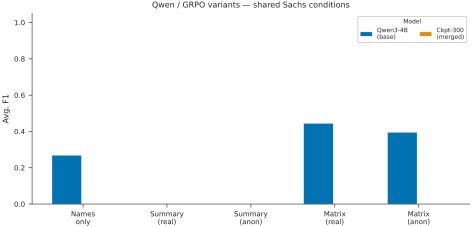

In [11]:
# ── Qwen / GRPO comparison bar chart ─────────────────────────────────────────
QWEN_PRETTY = {
    'Qwen3-4B-Thinking-2507':      'Qwen3-4B\n(base)',
    'checkpoint-300_merged_vllm': 'Ckpt-300\n(merged)',
}

COND_LABELS_Q = {
    'names_only':           'Names\nonly',
    'summary / real':       'Summary\n(real)',
    'summary / anon':       'Summary\n(anon)',
    'matrix / real':        'Matrix\n(real)',
    'matrix / anon':        'Matrix\n(anon)',
}
cond_order_q  = list(COND_LABELS_Q.keys())
q_model_order = list(QWEN_PRETTY.values())

plot_q = grpo_compare_best[grpo_compare_best['model'].isin(QWEN_PRETTY)].copy()
plot_q['display_model'] = plot_q['model'].map(QWEN_PRETTY)
plot_q = plot_q[plot_q['comparison_setting'].isin(cond_order_q)].copy()
plot_q['avg_f1'] = pd.to_numeric(plot_q['avg_f1'], errors='coerce')

# One best row per (model, condition) is already selected above.
plot_q_agg = (
    plot_q.groupby(['display_model', 'comparison_setting'], observed=True)['avg_f1']
    .mean()
    .reset_index()
)

q_palette = sns.color_palette('colorblind', n_colors=len(q_model_order))
q_color   = dict(zip(q_model_order, q_palette))

fig_q, ax = plt.subplots(figsize=(COL2_W, FIG_H * 1.4))

n_s     = len(cond_order_q)
n_m     = len(q_model_order)
width   = 0.78 / n_m
offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * width
x       = np.arange(n_s)

for i, model in enumerate(q_model_order):
    sub  = (plot_q_agg[plot_q_agg['display_model'] == model]
            .set_index('comparison_setting')
            .reindex(cond_order_q))
    vals = sub['avg_f1'].values
    ax.bar(x + offsets[i],
           np.where(np.isnan(vals), 0, vals),
           width=width * 0.9,
           color=q_color[model],
           label=model,
           edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([COND_LABELS_Q[s] for s in cond_order_q])
ax.set_ylabel('Avg. F1')
ax.set_ylim(0, 1.05)
ax.set_title('Qwen / GRPO variants — shared Sachs conditions')
ax.legend(title='Model', ncol=2,
          fontsize=LEGEND_SIZE - 1, title_fontsize=LEGEND_SIZE - 1,
          loc='upper right')
sns.despine(ax=ax)
fig_q.tight_layout()

save_fig(fig_q, 'sachs_qwen_grpo_comparison')
plt.show()

In [9]:
main_table.to_csv(TABLE_DIR / 'sachs_main_table_avg.csv', index=False)
repr_table.to_csv(TABLE_DIR / 'sachs_representation_table_avg.csv')
semantic_audit.to_csv(TABLE_DIR / 'sachs_semantic_audit_avg.csv', index=False)
grpo_compare_best.to_csv(TABLE_DIR / 'sachs_qwen_grpo_comparison.csv', index=False)

print('Saved paper tables to:', TABLE_DIR)
print('Saved figures to:', FIG_DIR)


NameError: name 'main_table' is not defined